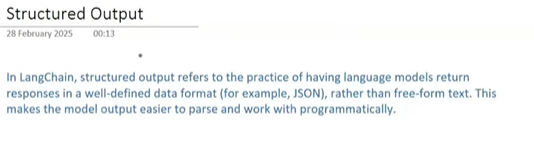

### Way to get the Strcutured output based on the LLM cabalities
- If an LLM can Provide the Structured Output in Langchain we use `.with_structured_output()`
- Typed Dict
- Pydantic
- Json Schema

- If an LLM can't Provide the Structured Output in Langchain we use `OutputParsers`

In [ ]:
from sqlalchemy.sql.annotation import Annotated
from typing import Literal
from typing import TypedDict

class Person(TypedDict):
    name: str
    age: int


new_person = Person(name="John", age=30)
print(new_person)

{'name': 'John', 'age': 30}


In [30]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

load_dotenv()


model = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0.7,
    max_tokens=1000,
    max_retries=2,
)


In [ ]:
from typing import TypedDict
from typing import Annotated

# Typed Dict
class Review(TypedDict):
    summary: Annotated[str, "A summary of the review"]
    stars: Annotated[int, "The number of stars given by the reviewer (1-25)"]
    sentiment: Annotated[ str, "Return sentiment of the review as positive or negative or neutral"]

structured_model = model.with_structured_output(Review)

result = structured_model.invoke("""The hardware is great, but the software feels bloated.
There are too many pre-installed apps that I can't remove. Also, the UI looks outdated
compared to other brands. Hoping for a software update to fix this.""")

print(type(result))
print(result)


print("\nSummary: ", result['summary'])
print("\nStars: ", result['stars'])
print("\nSentiment: ", result['sentiment'])


<class 'dict'>
{'name': 'The hardware is great, but the software feels bloated.', 'sentiment': 'negative', 'stars': 3, 'summary': 'Poor software quality and outdated UI'}

Summary:  Poor software quality and outdated UI

Stars:  3

Sentiment:  negative


In [27]:
from pydantic import BaseModel, Field
from typing import List

class Review(BaseModel):
    summary: str = Field(description="A summary of the review")
    stars: int = Field(description="The number of stars given by the reviewer (1-25)")
    sentiment: str = Field(description="Return sentiment of the review as positive or negative or neutral")
    pros: list[str] = Field(description="List of pros of the review")
    cons: list[str] = Field(description="List of cons of the review")

structured_model = model.with_structured_output(Review)

result = structured_model.invoke("""The hardware is great, but the software feels bloated.
There are too many pre-installed apps that I can't remove. Also, the UI looks outdated
compared to other brands. Hoping for a software update to fix this.""")

print(type(result))
print(result)


print("\nSummary: ", result.summary)
print("\nStars: ", result.stars)
print("\nSentiment: ", result.sentiment)

data= result.model_dump()
print(type(data))
print("\n",data)
print("\nSummary: ",data["summary"])
print("\nStars: ", data["stars"])
print("\nSentiment: ", data["sentiment"])


<class '__main__.Review'>
summary="The hardware is great, but the software feels bloated. There are too many pre-installed apps that I can't remove. Also, the UI looks outdated compared to other brands. Hoping for a software update to fix this." stars=2 sentiment='negative' pros=['great hardware'] cons=['software feels bloated', 'too many pre-installed apps', 'UI looks outdated']

Summary:  The hardware is great, but the software feels bloated. There are too many pre-installed apps that I can't remove. Also, the UI looks outdated compared to other brands. Hoping for a software update to fix this.

Stars:  2

Sentiment:  negative
<class 'dict'>

 {'summary': "The hardware is great, but the software feels bloated. There are too many pre-installed apps that I can't remove. Also, the UI looks outdated compared to other brands. Hoping for a software update to fix this.", 'stars': 2, 'sentiment': 'negative', 'pros': ['great hardware'], 'cons': ['software feels bloated', 'too many pre-install

In [35]:
json_schema = {
    "title": "Review",
    "type": "object",
    "properties": {
        "summary": {
        "type": "string",
        "description": "A summary of the review"
        },
        "stars": {
        "type": "integer",
        "description": "The number of stars given by the reviewer (1-25)"
        },
        "sentiment": {
        "type": "string",
        "description": "Return sentiment of the review as positive, negative or neutral"
        },
        "pros": {
        "type": "array",
        "items": {
            "type": "string"
        },
        "description": "List of pros of the review"
        },
        "cons": {
        "type": "array",
        "items": {
            "type": "string"
        },
        "description": "List of cons of the review"
        }
    },
    "required": ["summary", "stars", "sentiment", "pros", "cons"]
    }


structured_model = model.with_structured_output(json_schema)

result = structured_model.invoke("""The hardware is great, but the software feels bloated.
There are too many pre-installed apps that I can't remove. Also, the UI looks outdated
compared to other brands. Hoping for a software update to fix this.""")

print(type(result))
print(result)


print("\nSummary: ", result['summary'])
print("\nStars: ", result['stars'])
print("\nSentiment: ", result['sentiment'])

<class 'dict'>
{'cons': ['software feels bloated', 'too many pre-installed apps', 'UI looks outdated'], 'pros': ['hardware is great'], 'sentiment': 'negative', 'stars': 3, 'summary': 'Disappointing software experience'}

Summary:  Disappointing software experience

Stars:  3

Sentiment:  negative


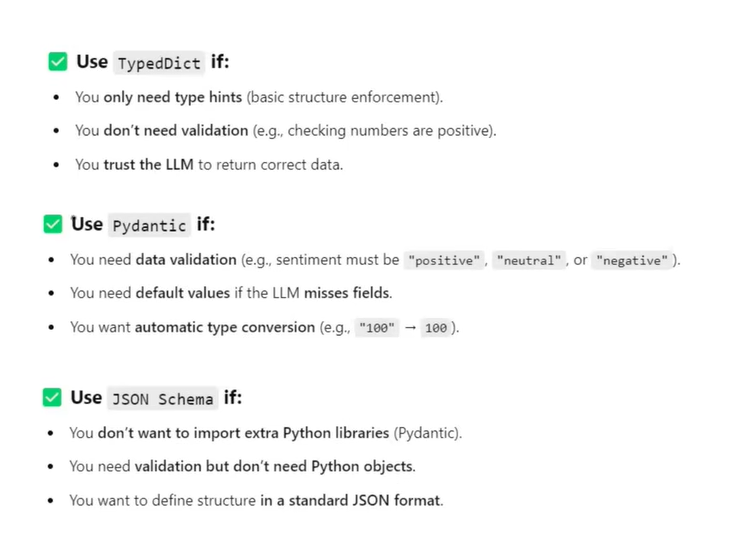